In [209]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from matplotlib.pyplot import cm

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [210]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [211]:
# Preparation
pilot_analysis = False
unique_subject_ids = [3,4]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
unique_sessions = [1,2,3,4]
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [212]:
if not recent_results:
    raise Exception('No files found')
else:
    print(recent_results)

['/Volumes/project/3025011.02/raw/sub-003/ses-mri01/beh/behavioural_output_sub-003_session-01_dummy_2025-02-06_10-42-51.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri02/beh/behavioural_output_sub-003_session-02_skyra_2025-02-13_12-00-57.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri03/beh/behavioural_output_sub-003_session-03_skyra_2025-02-18_15-30-50.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri04/beh/behavioural_output_sub-003_session-04_skyra_2025-02-21_16-11-25.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri01/beh/behavioural_output_sub-004_session-01_dummy_2025-02-19_14-33-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri02/beh/behavioural_output_sub-004_session-02_dummy_2025-02-20_11-40-53.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri03/beh/behavioural_output_sub-004_session-03_skyra_2025-02-25_15-34-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri04/beh/behavioural_output_sub-004_session-04_skyra_2025-03-03_17-11-46.csv']

### Remove invalid files

In [213]:
# Remove files that contain invalid data
raw_output_path = '/Volumes/project/3025011.02/raw/'
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/raw/sub-003/ses-mri01/beh/behavioural_output_sub-003_session-01_dummy_2025-02-06_10-42-51.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri02/beh/behavioural_output_sub-003_session-02_skyra_2025-02-13_12-00-57.csv', '/Volumes/project/3025011.02/raw/sub-003/ses-mri04/beh/behavioural_output_sub-003_session-04_skyra_2025-02-21_16-11-25.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri01/beh/behavioural_output_sub-004_session-01_dummy_2025-02-19_14-33-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri02/beh/behavioural_output_sub-004_session-02_dummy_2025-02-20_11-40-53.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri03/beh/behavioural_output_sub-004_session-03_skyra_2025-02-25_15-34-39.csv', '/Volumes/project/3025011.02/raw/sub-004/ses-mri04/beh/behavioural_output_sub-004_session-04_skyra_2025-03-03_17-11-46.csv']


In [214]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if pilot_analysis:
    combined_results_dataframe.rename(columns={'iti': 'trial_duration'}, inplace=True)
    combined_results_dataframe['stimuli_type'] = combined_results_dataframe['stimuli_type'].replace(3, 2)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.738835e+09      NaN                Late   
1         1        1.738835e+09       up                Even   
2         2        1.738835e+09       up                Even   
3         3        1.738835e+09       up                Even   
4         4        1.738835e+09     down                Even   
...     ...                 ...      ...                 ...   
4671    663        1.741021e+09       up                True   
4672    664        1.741021e+09       up                True   
4673    665        1.741021e+09       up                True   
4674    666        1.741021e+09       up                True   
4675    667        1.741021e+09       up               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    Late   1.738835e+09  1.211   1.738835e+09             2   
1                    True   1.738835e+09  0.428   1.738835e+09         

# Flip results if joystick orientation was incorrect
Specifically, switch the response and probability

In [215]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_results_dataframe['sub_session'] = combined_results_dataframe['subject_id'] + '_' + combined_results_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_results_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_results_dataframe.loc[mask, 'probability_condition'] = (
    combined_results_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_results_dataframe.loc[mask, 'response'] = (
    combined_results_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_results_dataframe.drop(columns='sub_session', inplace=True)

print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.738835e+09      NaN                Late   
1         1        1.738835e+09       up                Even   
2         2        1.738835e+09       up                Even   
3         3        1.738835e+09       up                Even   
4         4        1.738835e+09     down                Even   
...     ...                 ...      ...                 ...   
4671    663        1.741021e+09     down                True   
4672    664        1.741021e+09     down                True   
4673    665        1.741021e+09     down                True   
4674    666        1.741021e+09     down                True   
4675    667        1.741021e+09     down               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    Late   1.738835e+09  1.211   1.738835e+09             2   
1                    True   1.738835e+09  0.428   1.738835e+09         

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [216]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [217]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                2                     50    undefined
1                1                     50    undefined
2                2                     50    undefined
3                1                     50    undefined
4                1                     50    undefined
...            ...                    ...          ...
4671             1                     20  incongruent
4672             1                     20  incongruent
4673             1                     20  incongruent
4674             1                     20  incongruent
4675             2                     80  incongruent

[4676 rows x 3 columns]


In [218]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

      stimuli_type valence
0                2   happy
1                1   angry
2                2   happy
3                1   angry
4                1   angry
...            ...     ...
4671             1   angry
4672             1   angry
4673             1   angry
4674             1   angry
4675             2   happy

[4676 rows x 2 columns]


In [219]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Objectively correct answer binned after every switch
Sorted for valence

In [220]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'valence', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'valence'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch valence
10      sub-003     10             1                     80  False   angry
11      sub-003     11             1                     80  False   angry
13      sub-003     13             1                     80  False   angry
14      sub-003     14             1                     80  False   angry
16      sub-003     16             1                     80  False   angry
...         ...    ...           ...                    ...    ...     ...
4667    sub-004    659             2                     80  False   happy
4668    sub-004    660             2                     80  False   happy
4669    sub-004    661             2                     80  False   happy
4670    sub-004    662             2                     80  False   happy
4675    sub-004    667             2                     80  False   happy

[4620 rows x 6 columns]
0   subject_id stimuli_type valence  0  1  2  3  4  5
1      sub-003       

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

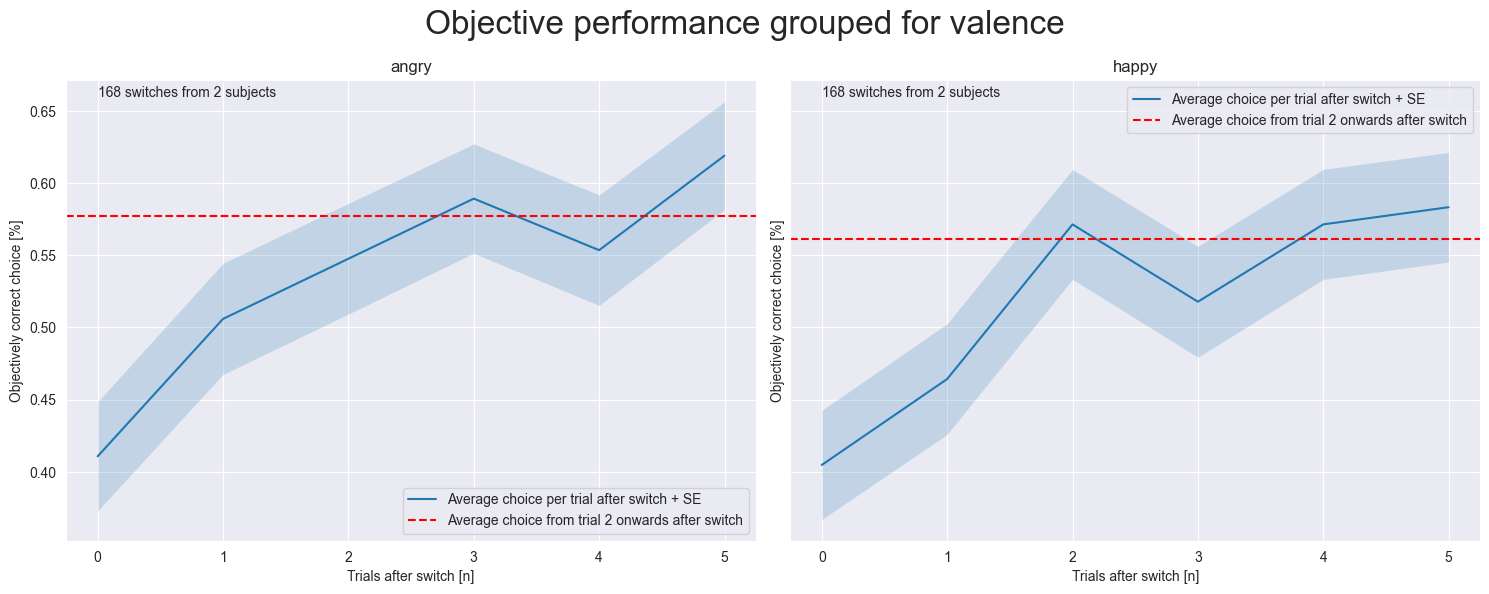

In [221]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['valence'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['valence']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['valence']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

congruency_list = df['valence'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.66, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence.pdf'))
plt.show()

# Now the same but split for congruency

In [222]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
10      sub-003     10             1                     80  False   
11      sub-003     11             1                     80  False   
13      sub-003     13             1                     80  False   
14      sub-003     14             1                     80  False   
16      sub-003     16             1                     80  False   
...         ...    ...           ...                    ...    ...   
4667    sub-004    659             2                     80  False   
4668    sub-004    660             2                     80  False   
4669    sub-004    661             2                     80  False   
4670    sub-004    662             2                     80  False   
4675    sub-004    667             2                     80  False   

       congruency  
10      congruent  
11      congruent  
13      congruent  
14      congruent  
16      congruent  
...           ...  
4667  incongruent  

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

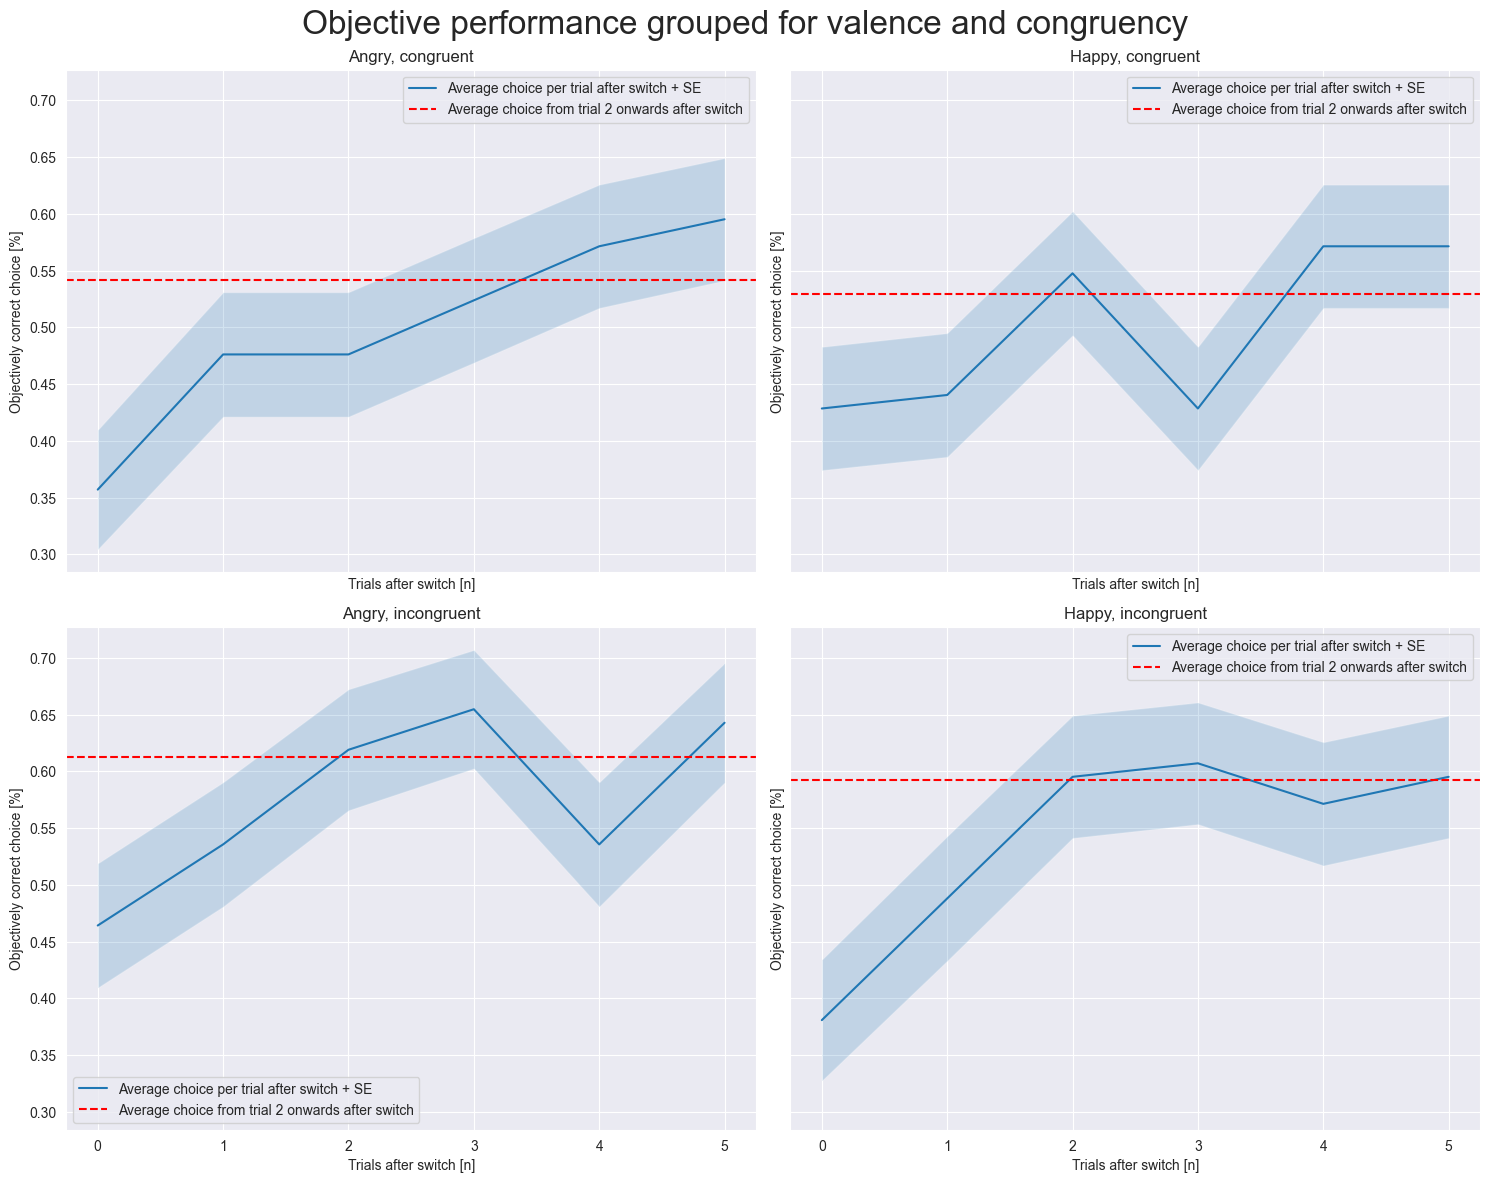

In [223]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [224]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch response
10      sub-003     10             1                     80  False     down
11      sub-003     11             1                     80  False       up
13      sub-003     13             1                     80  False       up
14      sub-003     14             1                     80  False       up
16      sub-003     16             1                     80  False     down
...         ...    ...           ...                    ...    ...      ...
4667    sub-004    659             2                     80  False       up
4668    sub-004    660             2                     80  False      NaN
4669    sub-004    661             2                     80  False     down
4670    sub-004    662             2                     80  False       up
4675    sub-004    667             2                     80  False     down

[4620 rows x 6 columns]
0   subject_id stimuli_type response  0  1  2  3  4  5
1      s

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

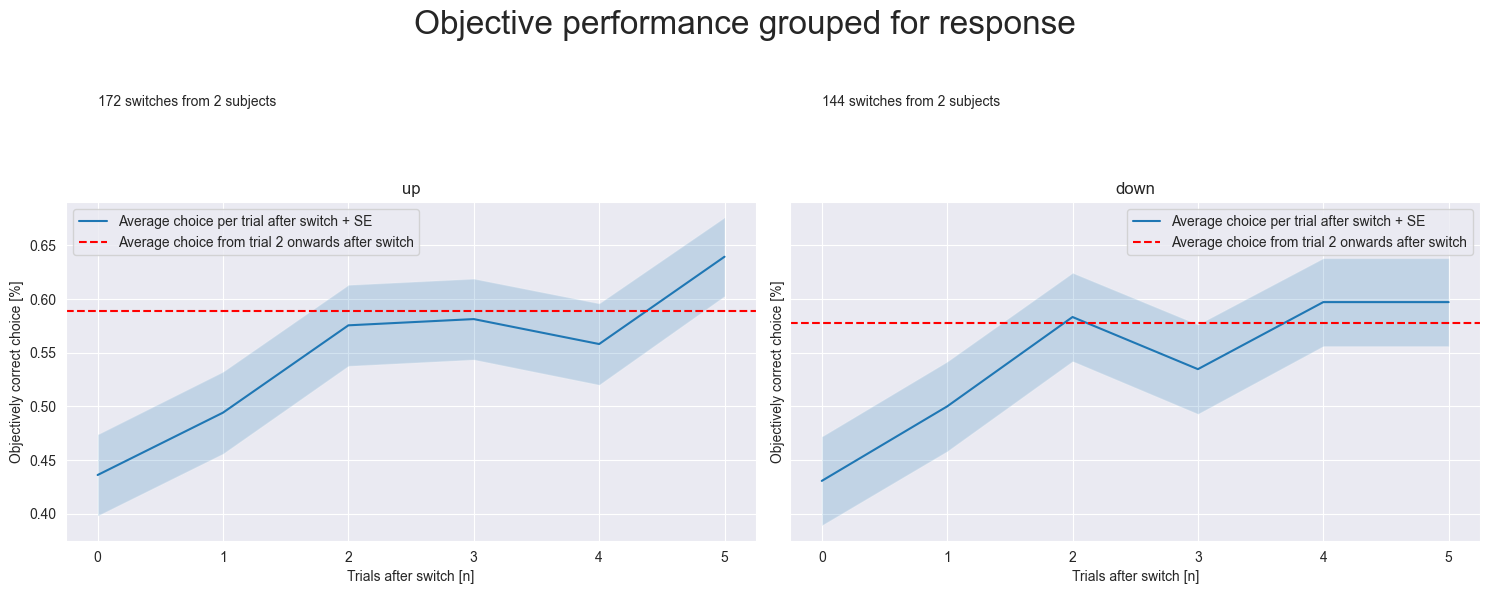

In [225]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [226]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
10      sub-003     10             1                     80  False   
11      sub-003     11             1                     80  False   
13      sub-003     13             1                     80  False   
14      sub-003     14             1                     80  False   
16      sub-003     16             1                     80  False   
...         ...    ...           ...                    ...    ...   
4667    sub-004    659             2                     80  False   
4668    sub-004    660             2                     80  False   
4669    sub-004    661             2                     80  False   
4670    sub-004    662             2                     80  False   
4675    sub-004    667             2                     80  False   

       congruency response  
10      congruent     down  
11      congruent       up  
13      congruent       up  
14      congruent       up  
16      congru

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

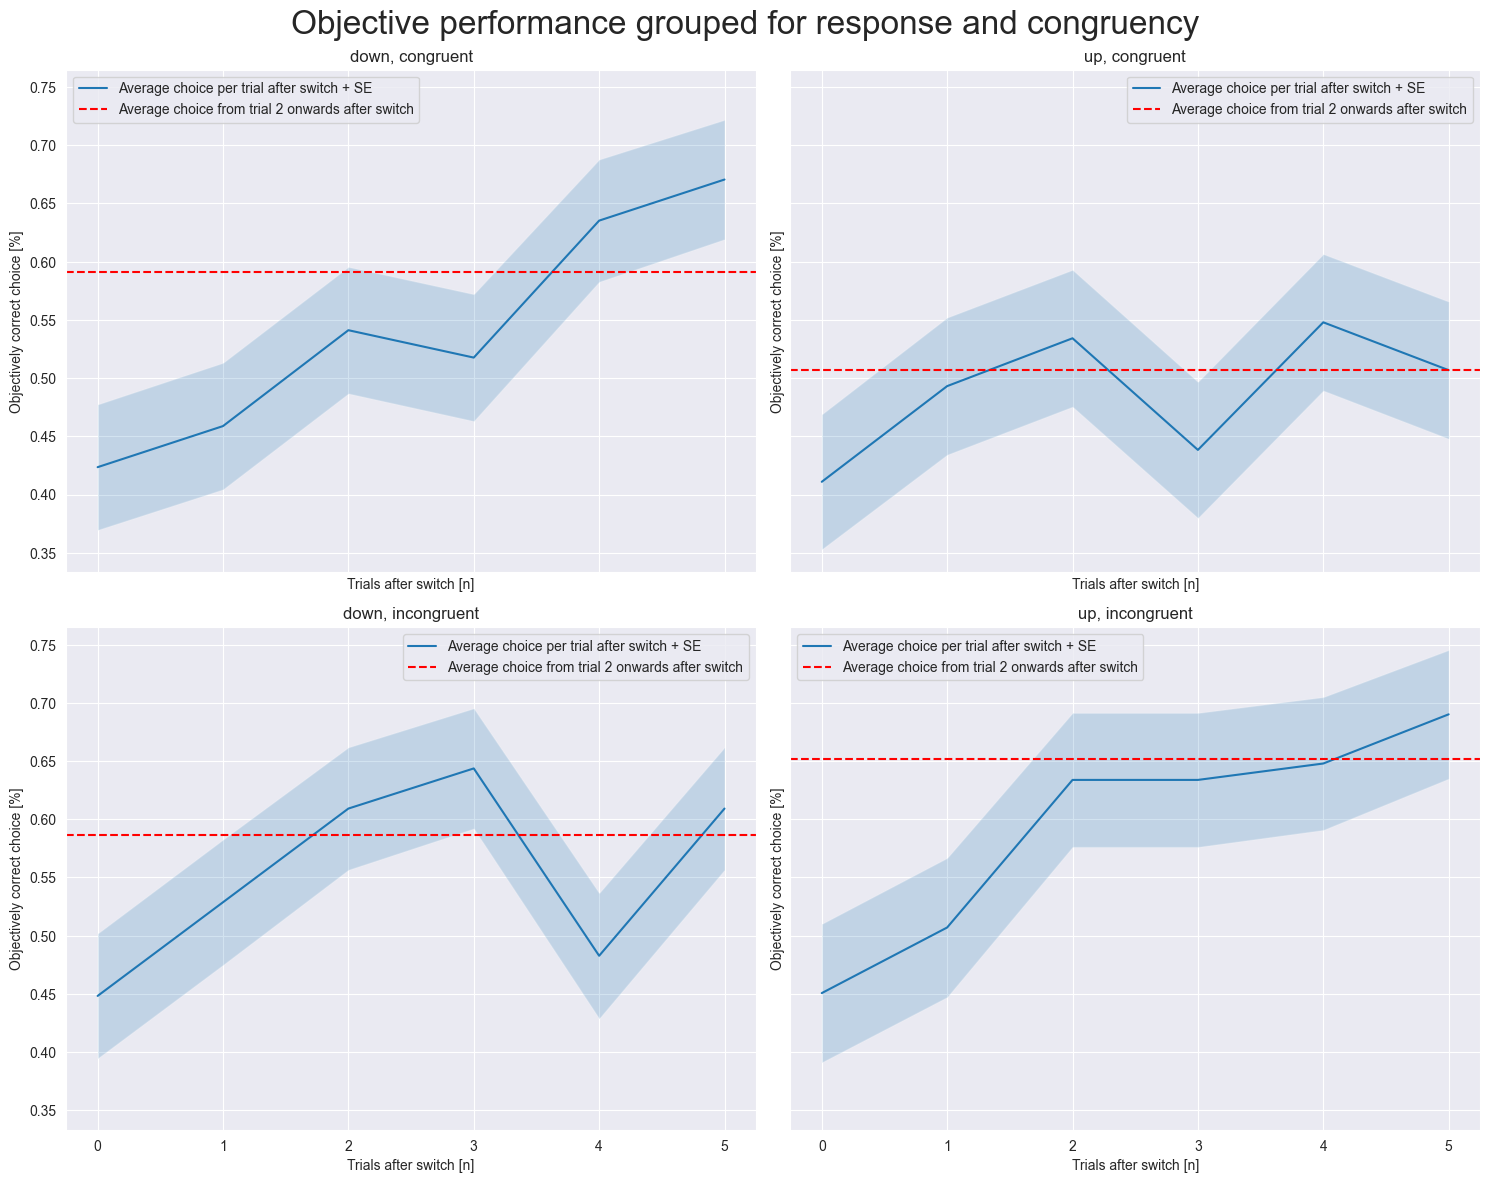

In [227]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
        axs[i].set_xlabel('Trials after switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [228]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_switches_dataframe)

'''
for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-10:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -10, 3: -9, 4: -8, 5: -7, 6: -6, 7: -5, 8: -4, 9: -3, 10: -2, 11: -1, 12: 0, 13: 1, 14: 2, 15: 3, 16: 4})
'''

     subject_id  trial  stimuli_type  probability_condition switch response
10      sub-003     10             1                     80  False     down
11      sub-003     11             1                     80  False       up
13      sub-003     13             1                     80  False       up
14      sub-003     14             1                     80  False       up
16      sub-003     16             1                     80  False     down
...         ...    ...           ...                    ...    ...      ...
4667    sub-004    659             2                     80  False       up
4668    sub-004    660             2                     80  False      NaN
4669    sub-004    661             2                     80  False     down
4670    sub-004    662             2                     80  False       up
4675    sub-004    667             2                     80  False     down

[4620 rows x 6 columns]
0   subject_id stimuli_type response  -5  -4  -3  -2  -1  0  1 

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

"\nfor index_stimuli in unique_stimuli_types:\n    for index_subject_id in unique_subject_ids:\n        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]\n\n        # Add column that notes if a switch occurred recently\n        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)\n        # Filter out trials with 50% reward probability\n        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()\n        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)\n\n        # Add switches to a list\n        switches_reward = dataf

In [229]:
'''
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('stimuli_type')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[stimuli_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_binned_around_switch.pdf'))
plt.show()
'''

"\n# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily\ndf = all_switches_dataframe.set_index('stimuli_type')\n\nsubject_counts = len(df['subject_id'].unique())\n\n# Count the number of times both conditions were shown\ngroup_counts = df.index.value_counts()\n\n# We are not using 'subject_id', so let's exclude it from our calculations\ndf = df.drop(columns=['subject_id'])\n\n# Calculate the mean and standard deviation for each timepoint and stimuli_type\nmeans = df.groupby('stimuli_type').mean()\naverage_choice_after_switch_total = means.mean(axis=1).tolist()\nstds = df.groupby('stimuli_type').sem()\n\n# Plotting\nfig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types\naxs = axs.flatten() # Flatten to iterate easily\n\nfig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)\n\nstimuli_types_list = ['Angry', 'Happy']\n\nstimuli_types = means.index\nfor i, stimuli_t

# Subplots for incongruent and congruent switches

In [230]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
10      sub-003     10             1                     80  False   
11      sub-003     11             1                     80  False   
13      sub-003     13             1                     80  False   
14      sub-003     14             1                     80  False   
16      sub-003     16             1                     80  False   
...         ...    ...           ...                    ...    ...   
4667    sub-004    659             2                     80  False   
4668    sub-004    660             2                     80  False   
4669    sub-004    661             2                     80  False   
4670    sub-004    662             2                     80  False   
4675    sub-004    667             2                     80  False   

       congruency     session  
10      congruent  session-01  
11      congruent  session-01  
13      congruent  session-01  
14      congruent  session-01  

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

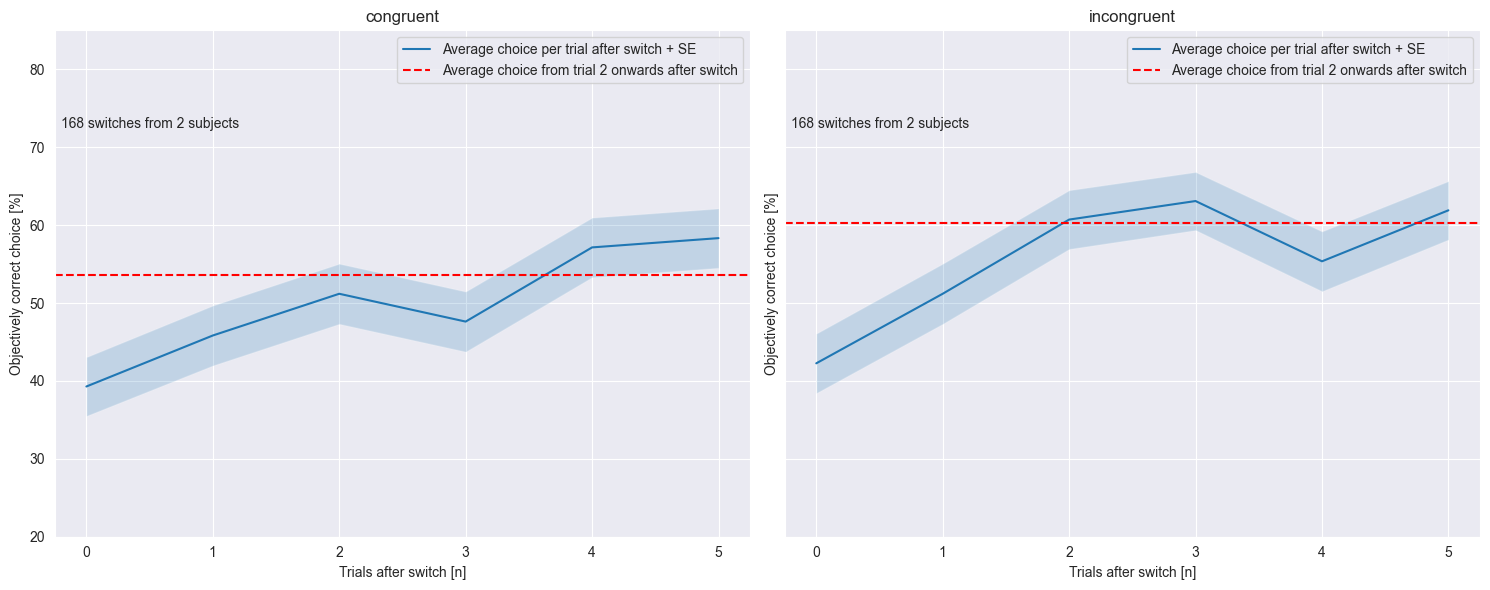

In [231]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials after switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

## Comparing congruency direction

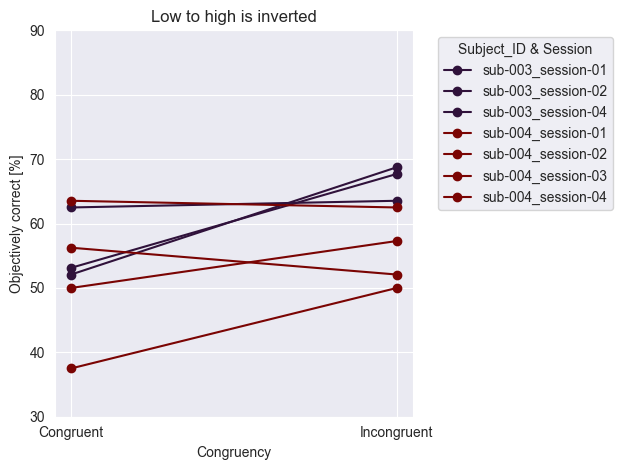

In [232]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')
df['subject_id_session'] = df['subject_id'] + '_' + df['session']

unique_subjects = df['subject_id_session'].unique()
subject_counts = len(unique_subjects)

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency','subject_id_session']).mean()
means_overall = means*100
means_overall = means_overall.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1)

df = average_choice_after_switch_total.reset_index()

# Create a mapping for congruency values to x-axis positions:
# 1 for 'congruent' and 2 for 'incongruent'
x_mapping = {'congruent': 1, 'incongruent': 2}
df['x'] = df['congruency'].map(x_mapping)

colour = iter(cm.turbo(np.linspace(0, 1, len(unique_subject_ids))))
prev_subject = None

# Loop through each subject and plot their corresponding data points
for subject in df['subject_id_session'].unique():
    subject_data = df[df['subject_id_session'] == subject].sort_values(by='x')
    subject_data['value'] = subject_data.iloc[:,2]
    value_congruent = subject_data.loc[subject_data['congruency'] == 'congruent', 'value'].iloc[0]
    value_incongruent = subject_data.loc[subject_data['congruency'] == 'incongruent', 'value'].iloc[0]

    # If the subject changes, increment the counter
    current_subject = subject.split('_')[0]
    if current_subject != prev_subject:
        line_colour = next(colour)
        prev_subject = current_subject

    # Choose colour based on comparison: green if incongruent is lower, red if higher
    if value_incongruent < value_congruent:
        line_color = 'green'
    elif value_incongruent > value_congruent:
        line_color = 'red'
    else:
        line_color = 'blue'  # Fallback colour if both values are equal

    plt.plot(subject_data['x'], subject_data.iloc[:, 2], marker='o', label=subject, color=line_colour)

# Set x-axis ticks and labels
plt.xticks([1, 2], ['Congruent', 'Incongruent'])
plt.xlabel('Congruency')
plt.ylabel('Objectively correct [%]')  # Replace 'Value' with your actual y-axis label if needed
plt.title('Low to high is inverted')
plt.ylim(30, 90)

# Optional: display a legend if the number of subjects is not too high
plt.legend(title='Subject_ID & Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_comparing_congruency.pdf'))
plt.show()

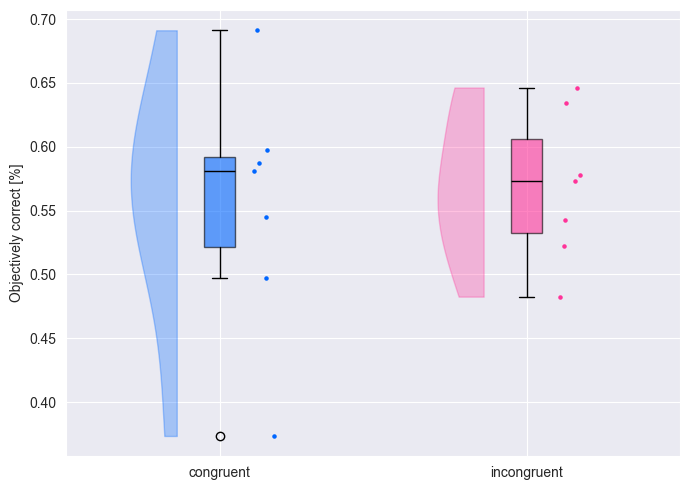

In [233]:
# Comparing overall congruency performance difference
dataframe_1 = combined_results_dataframe[combined_results_dataframe['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()
dataframe_2 = combined_results_dataframe[combined_results_dataframe['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()
combined_list = [list_1, list_2]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(combined_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(combined_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(combined_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=5, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Objectively correct [%]')
plot_name = 'all_trials_objective_performance_congruency'

# Save and show plot
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

# Overall objective performance over time
This will be used to check whether their performance stabilises after the 1st session

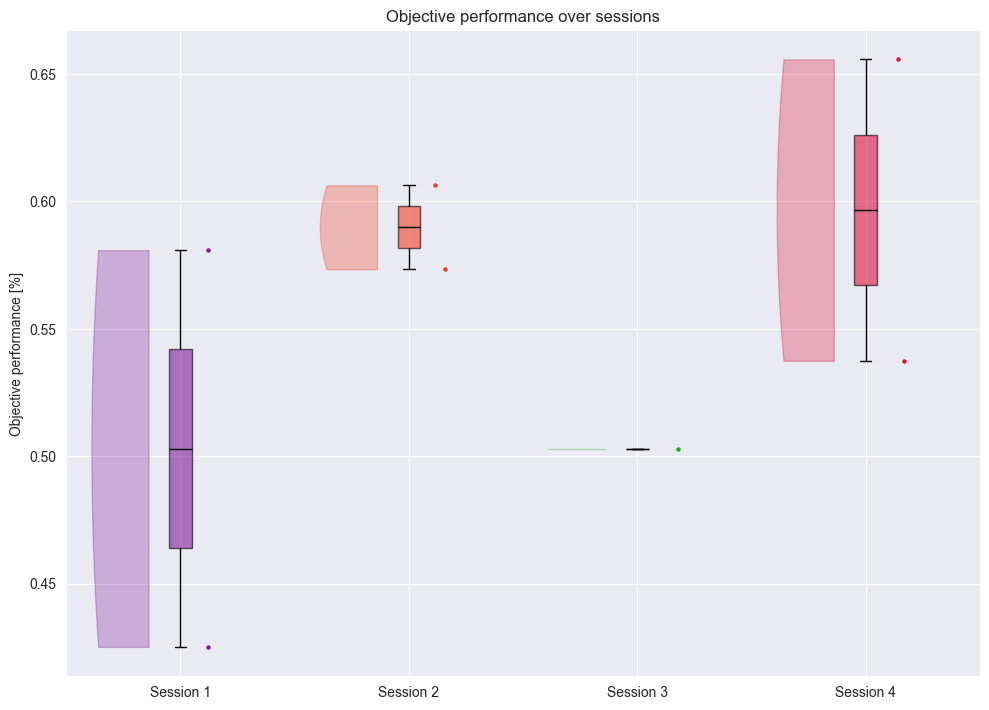

In [252]:
if 'session-04' in unique_sessions:
    dataframe_1 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-01']
    dataframe_1 = dataframe_1.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()

    dataframe_2 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-02']
    dataframe_2 = dataframe_2.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()

    dataframe_3 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-03']
    dataframe_3 = dataframe_3.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_3 = dataframe_3['objectively_correct_boolean'].dropna().tolist()

    dataframe_4 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-04']
    dataframe_4 = dataframe_4.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_4 = dataframe_4['objectively_correct_boolean'].dropna().tolist()

    valence_list = [list_1, list_2, list_3, list_4]

    # Create empty plot
    fig, ax = plt.subplots(figsize=(10, 7))

    # Create a list of colors
    plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
    c = 'black'

    # Boxplot data
    bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                    capprops=dict(color=c),
                    whiskerprops=dict(color=c),
                    flierprops=dict(color=c, markeredgecolor=c),
                    medianprops=dict(color=c))
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for median in bp['medians']:
        median.set_color('black')
    # Violinplot data (specify points as length data)
    vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                       showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
    # Change to the desired color
    for idx, b in enumerate(vp['bodies']): # Slices it in half
        # Change to the desired color
        b.set_color(plot_colors[idx])

    # Scatterplot data
    for idx, features in enumerate(valence_list):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .75)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
        x = out + 0.4
        plt.scatter(x, features, s=5, c=plot_colors[idx])

    # Allocate labels to x- and y-axis
    plt.xticks(np.arange(1,5,1), ['Session 1','Session 2','Session 3','Session 4'])  # Set text labels.
    plt.ylabel('Objective performance [%]')
    plot_name = 'Objective performance over sessions'

    # Save and show plot
    plt.tight_layout()
    plt.title(plot_name)
    plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
    plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [235]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1]]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range) 

print(dataframe)

[0, 28, 60, 66, 76, 84, 90, 98, 104, 136, 164, 172, 178, 188, 198, 208, 216, 246, 276, 284, 294, 300, 308, 318, 324, 330, 357, 389, 395, 405, 413, 419, 427, 433, 465, 492, 500, 506, 516, 526, 536, 544, 574, 603, 611, 621, 627, 635, 645, 651, 685, 715, 721, 727, 735, 741, 747, 755, 784, 816, 824, 834, 844, 854, 860, 870, 898, 930, 940, 948, 956, 964, 974, 980, 986, 1013, 1043, 1049, 1055, 1063, 1069, 1075, 1083, 1113, 1145, 1153, 1163, 1173, 1183, 1189, 1199, 1227, 1258, 1268, 1276, 1284, 1292, 1302, 1308, 1314, 1320, 1325, 1331, 1341, 1349, 1359, 1387, 1419, 1425, 1433, 1443, 1451, 1457, 1465, 1493, 1523, 1531, 1541, 1551, 1559, 1565, 1575, 1607, 1637, 1643, 1649, 1655, 1661, 1671, 1679, 1689, 1717, 1749, 1755, 1763, 1773, 1781, 1787, 1795, 1823, 1853, 1861, 1871, 1881, 1889, 1895, 1905, 1937, 1967, 1973, 1981, 1987, 1993, 2001, 2009, 2076, 2080, 2087, 2092, 2097, 2125, 2151, 2156, 2161, 2170, 2178, 2184, 2190, 2239, 2247, 2253, 2259, 2267, 2275, 2285, 2311, 2332, 2342, 2347, 2360, 236

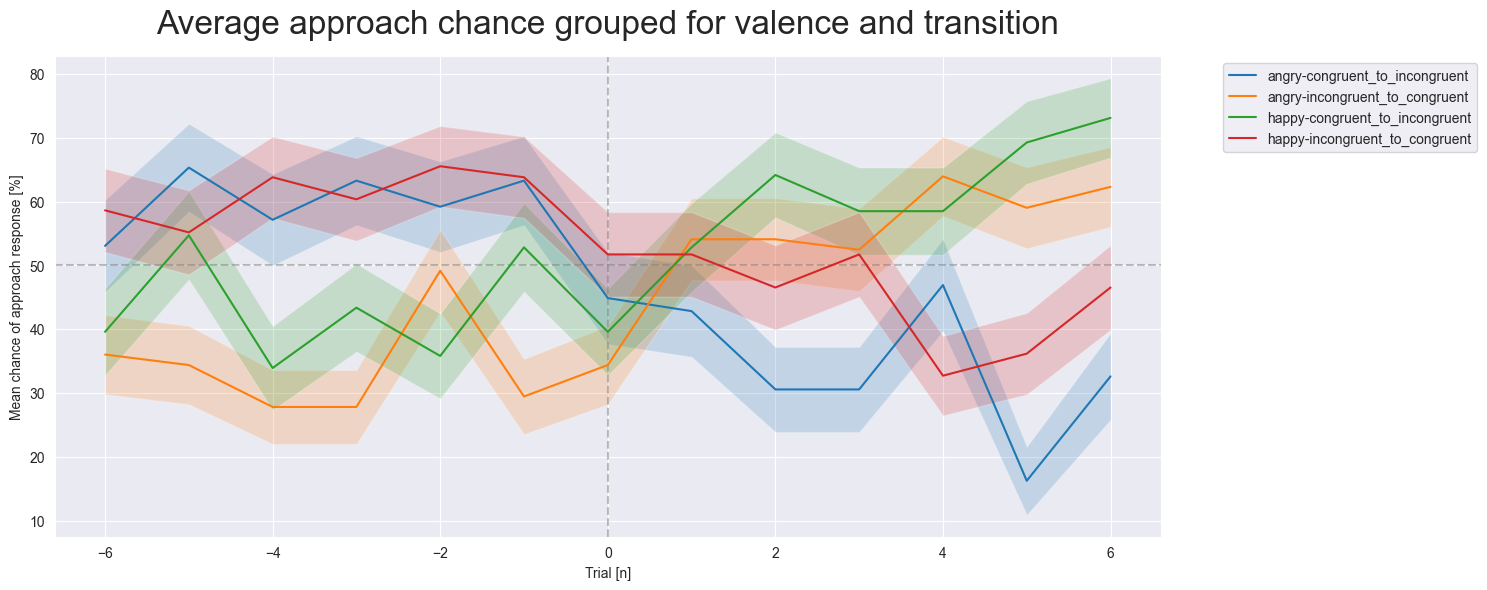

In [236]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

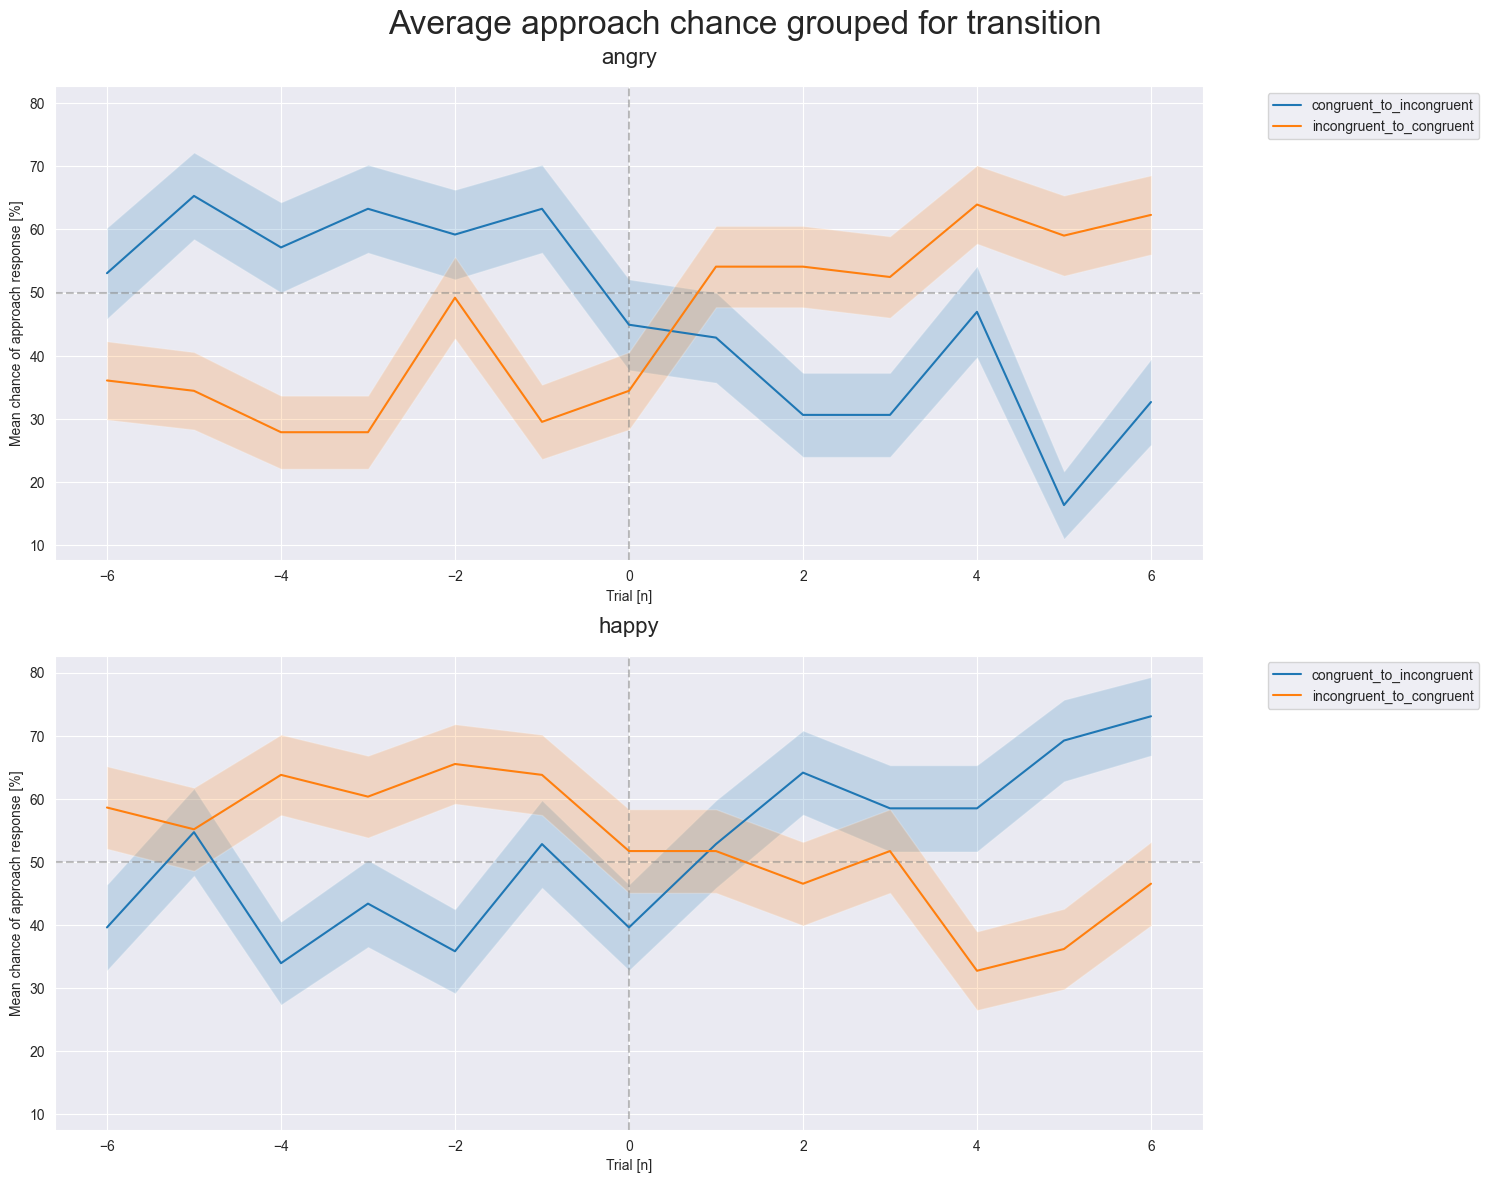

In [237]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [238]:
pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe[['subject_id', 'session', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:235: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


     subject_id     session  trial  stimuli_type  probability_condition  \
20      sub-003  session-01     10             1                     80   
27      sub-003  session-01     11             1                     80   
39      sub-003  session-01     13             1                     80   
45      sub-003  session-01     14             1                     80   
61      sub-003  session-01     16             1                     80   
70      sub-003  session-01     18             1                     80   
81      sub-003  session-01     19             1                     80   
106     sub-003  session-01     23             1                     80   
116     sub-003  session-01     24             1                     80   
121     sub-003  session-01     25             1                     80   
147     sub-003  session-01     29             1                     80   
159     sub-003  session-01     30             1                     80   
173     sub-003  session-

In [239]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

pd.set_option('display.max_rows', 20)

     subject_id  trial  stimuli_type  probability_condition switch volatility
20      sub-003     10             1                     80  False   volatile
27      sub-003     11             1                     80  False   volatile
39      sub-003     13             1                     80  False   volatile
45      sub-003     14             1                     80  False   volatile
61      sub-003     16             1                     80  False   volatile
70      sub-003     18             1                     80  False   volatile
81      sub-003     19             1                     80  False     stable
106     sub-003     23             1                     80  False     stable
116     sub-003     24             1                     80  False     stable
121     sub-003     25             1                     80  False     stable
147     sub-003     29             1                     80  False     stable
159     sub-003     30             1                     80  Fal

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

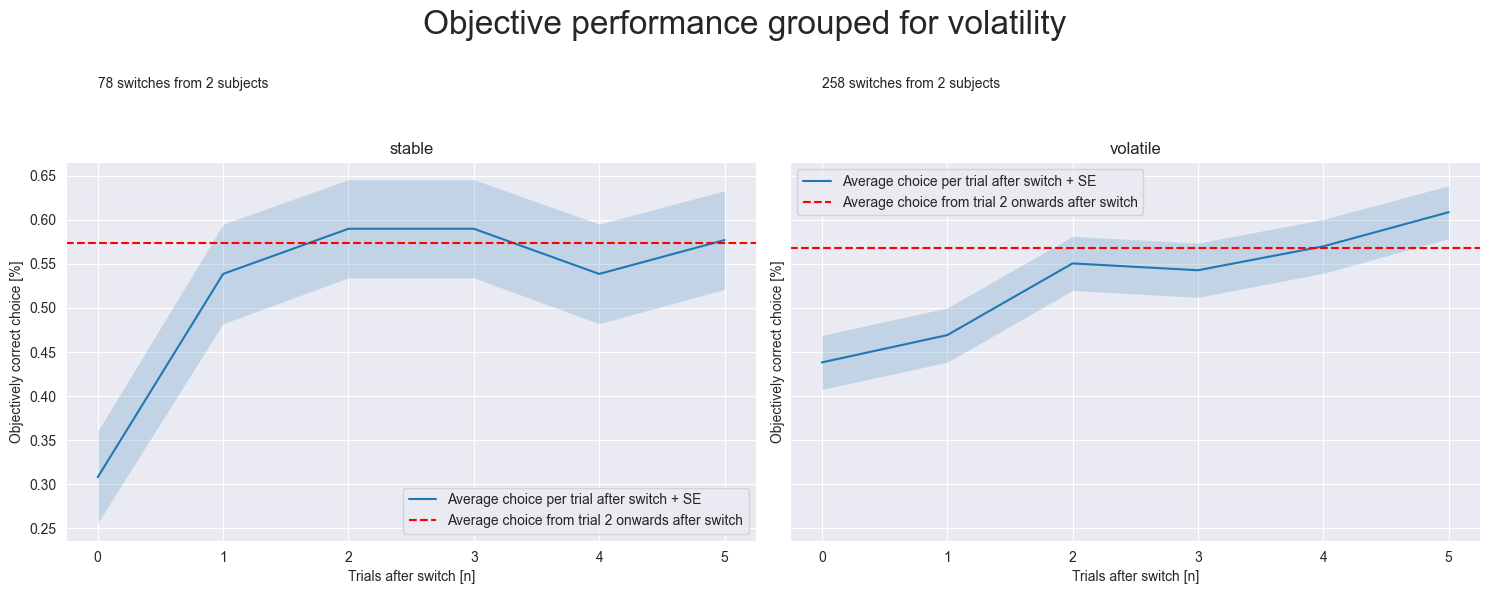

In [240]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.75, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

# Now do the same thing but split them for congruency

In [241]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe)

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}#, 11:7, 12:8, 13: 9, 14: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:235: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


      trial  emotional_cue_time response objectively_correct  \
20       10        1.738835e+09     down               False   
27       11        1.738835e+09       up                True   
39       13        1.738835e+09       up                True   
45       14        1.738835e+09       up                True   
61       16        1.738835e+09     down               False   
...     ...                 ...      ...                 ...   
4560    659        1.741021e+09       up                True   
4566    660        1.741021e+09      NaN                Late   
4571    661        1.741021e+09     down               False   
4581    662        1.741021e+09       up                True   
4619    667        1.741021e+09     down               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
20                  False   1.738835e+09  0.569   1.738835e+09             1   
27                   True   1.738835e+09  0.471   1.738835e+09         

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

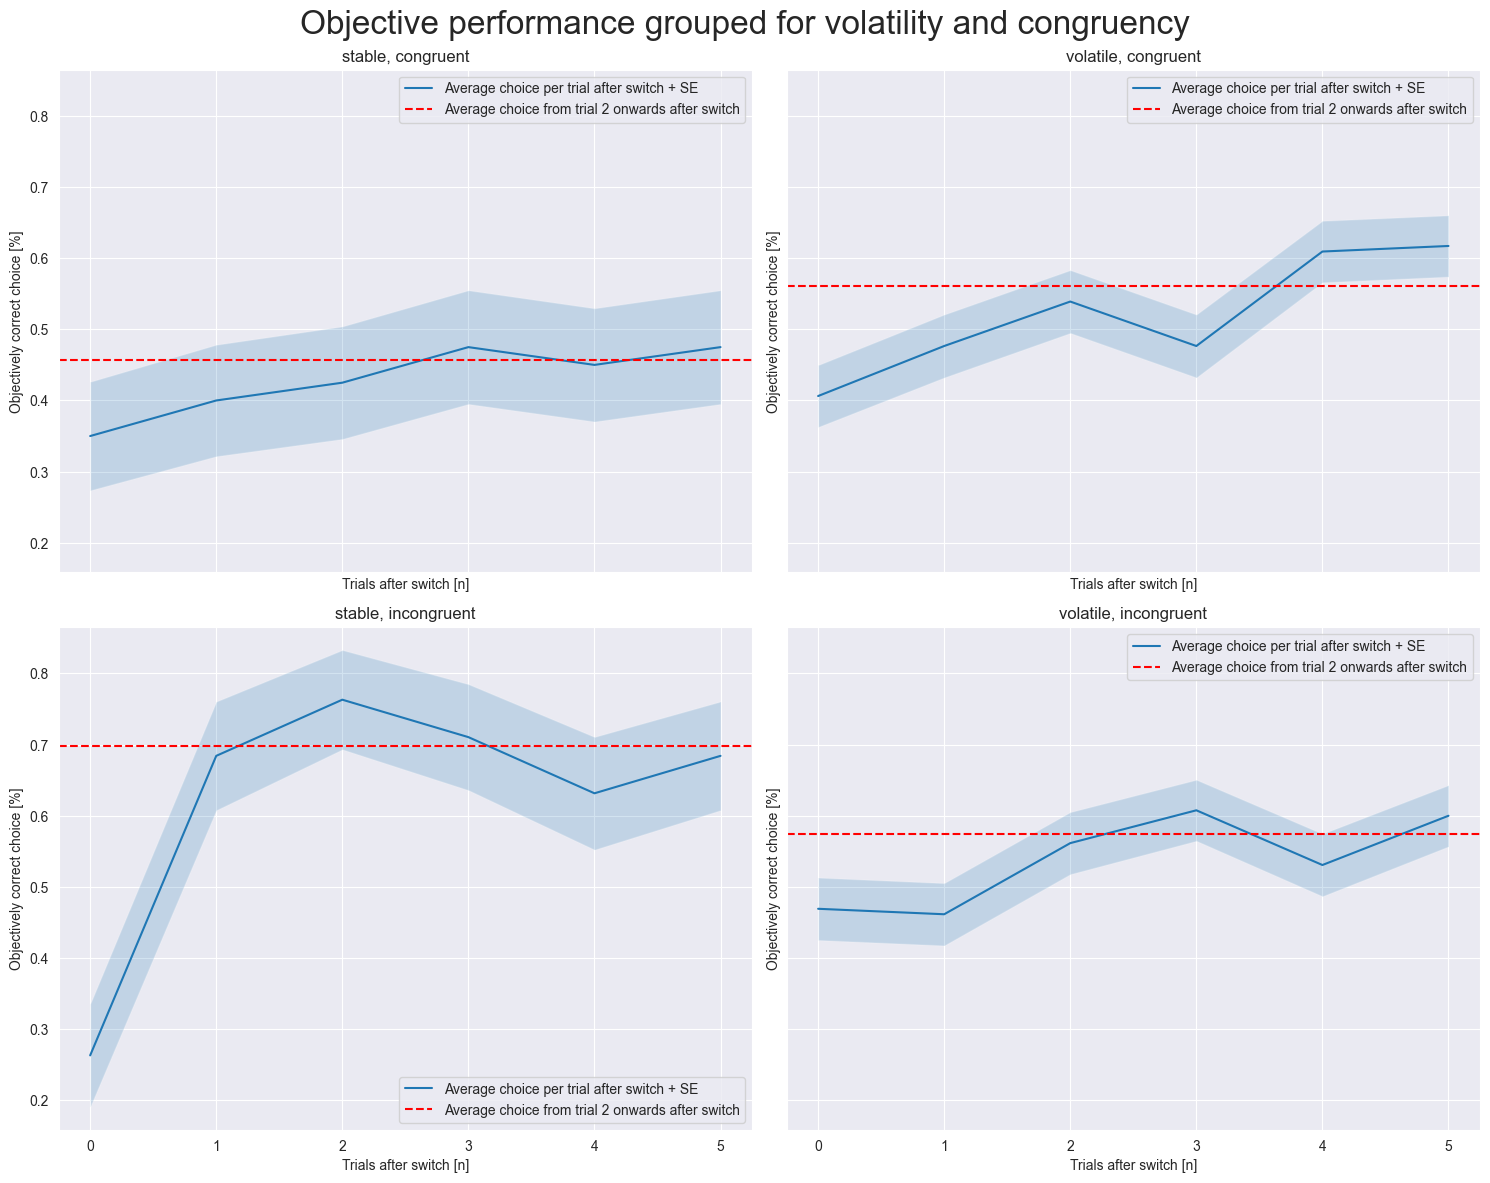

In [242]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

# Plot the full stable block

In [243]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:235: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


     subject_id  trial  stimuli_type  probability_condition switch volatility
20      sub-003     10             1                     80  False   volatile
27      sub-003     11             1                     80  False   volatile
39      sub-003     13             1                     80  False   volatile
45      sub-003     14             1                     80  False   volatile
61      sub-003     16             1                     80  False   volatile
...         ...    ...           ...                    ...    ...        ...
4560    sub-004    659             2                     80  False   volatile
4566    sub-004    660             2                     80  False   volatile
4571    sub-004    661             2                     80  False   volatile
4581    sub-004    662             2                     80  False   volatile
4619    sub-004    667             2                     80  False   volatile

[4620 rows x 6 columns]
0   subject_id stimuli_type volatility 

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:566: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

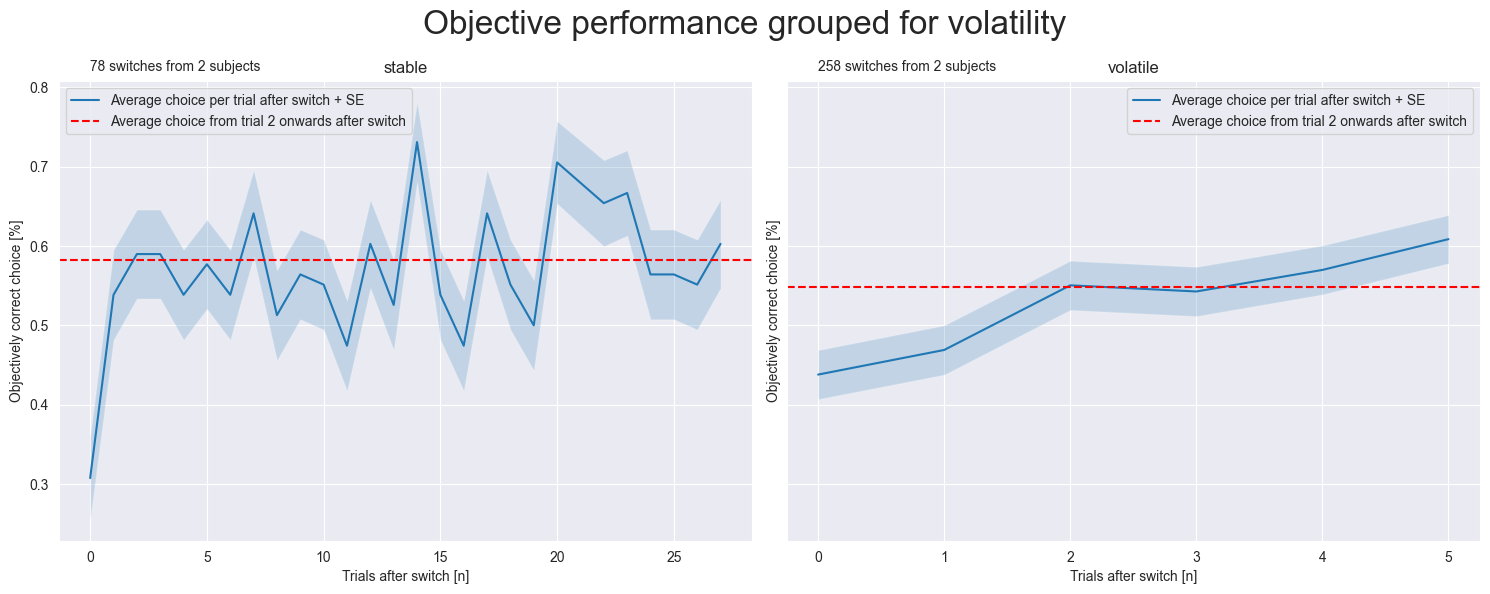

In [244]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_switch_total[i], color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [245]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a switch
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1]]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:235: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


[0, 28, 60, 66, 76, 84, 90, 98, 104, 136, 164, 172, 178, 188, 198, 208, 216, 246, 276, 284, 294, 300, 308, 318, 324, 330, 357, 389, 395, 405, 413, 419, 427, 433, 465, 492, 500, 506, 516, 526, 536, 544, 574, 603, 611, 621, 627, 635, 645, 651, 685, 715, 721, 727, 735, 741, 747, 755, 784, 816, 824, 834, 844, 854, 860, 870, 898, 930, 940, 948, 956, 964, 974, 980, 986, 1013, 1043, 1049, 1055, 1063, 1069, 1075, 1083, 1113, 1145, 1153, 1163, 1173, 1183, 1189, 1199, 1227, 1258, 1268, 1276, 1284, 1292, 1302, 1308, 1314, 1320, 1325, 1331, 1341, 1349, 1359, 1387, 1419, 1425, 1433, 1443, 1451, 1457, 1465, 1493, 1523, 1531, 1541, 1551, 1559, 1565, 1575, 1607, 1637, 1643, 1649, 1655, 1661, 1671, 1679, 1689, 1717, 1749, 1755, 1763, 1773, 1781, 1787, 1795, 1823, 1853, 1861, 1871, 1881, 1889, 1895, 1905, 1937, 1967, 1973, 1981, 1987, 1993, 2001, 2009, 2076, 2080, 2087, 2092, 2097, 2125, 2151, 2156, 2161, 2170, 2178, 2184, 2190, 2239, 2247, 2253, 2259, 2267, 2275, 2285, 2311, 2332, 2342, 2347, 2360, 236

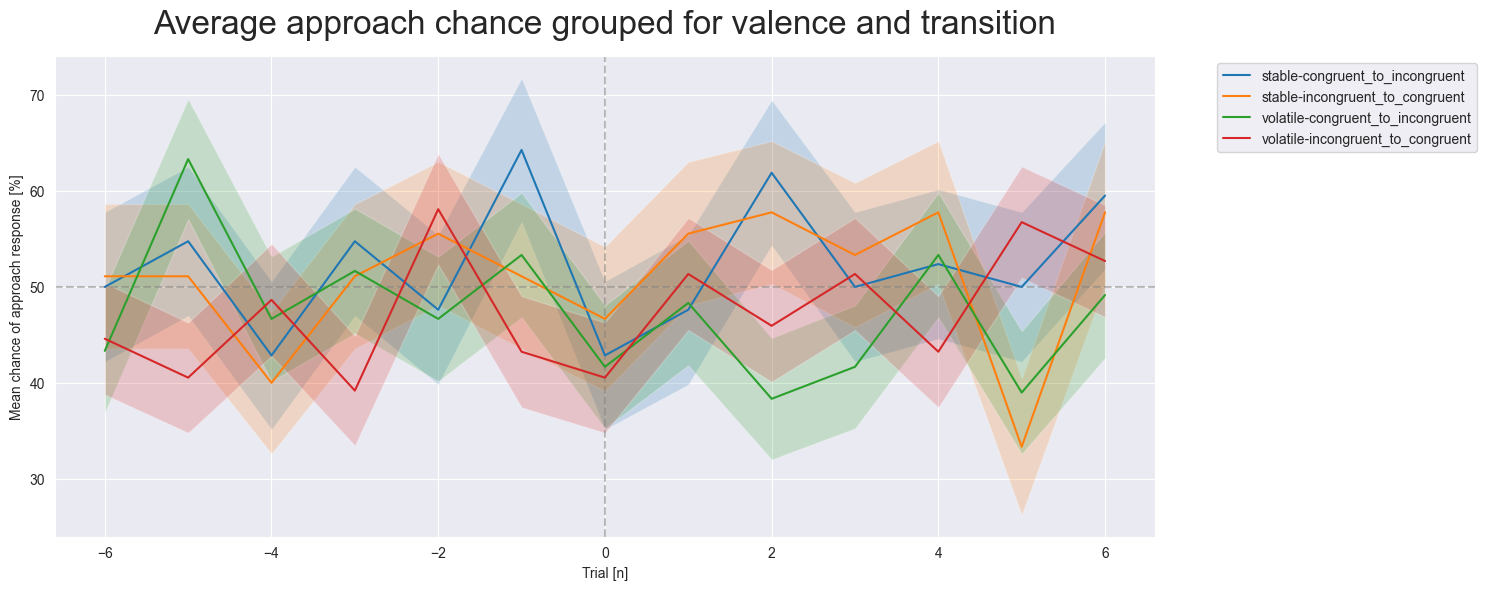

In [246]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'volatility', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

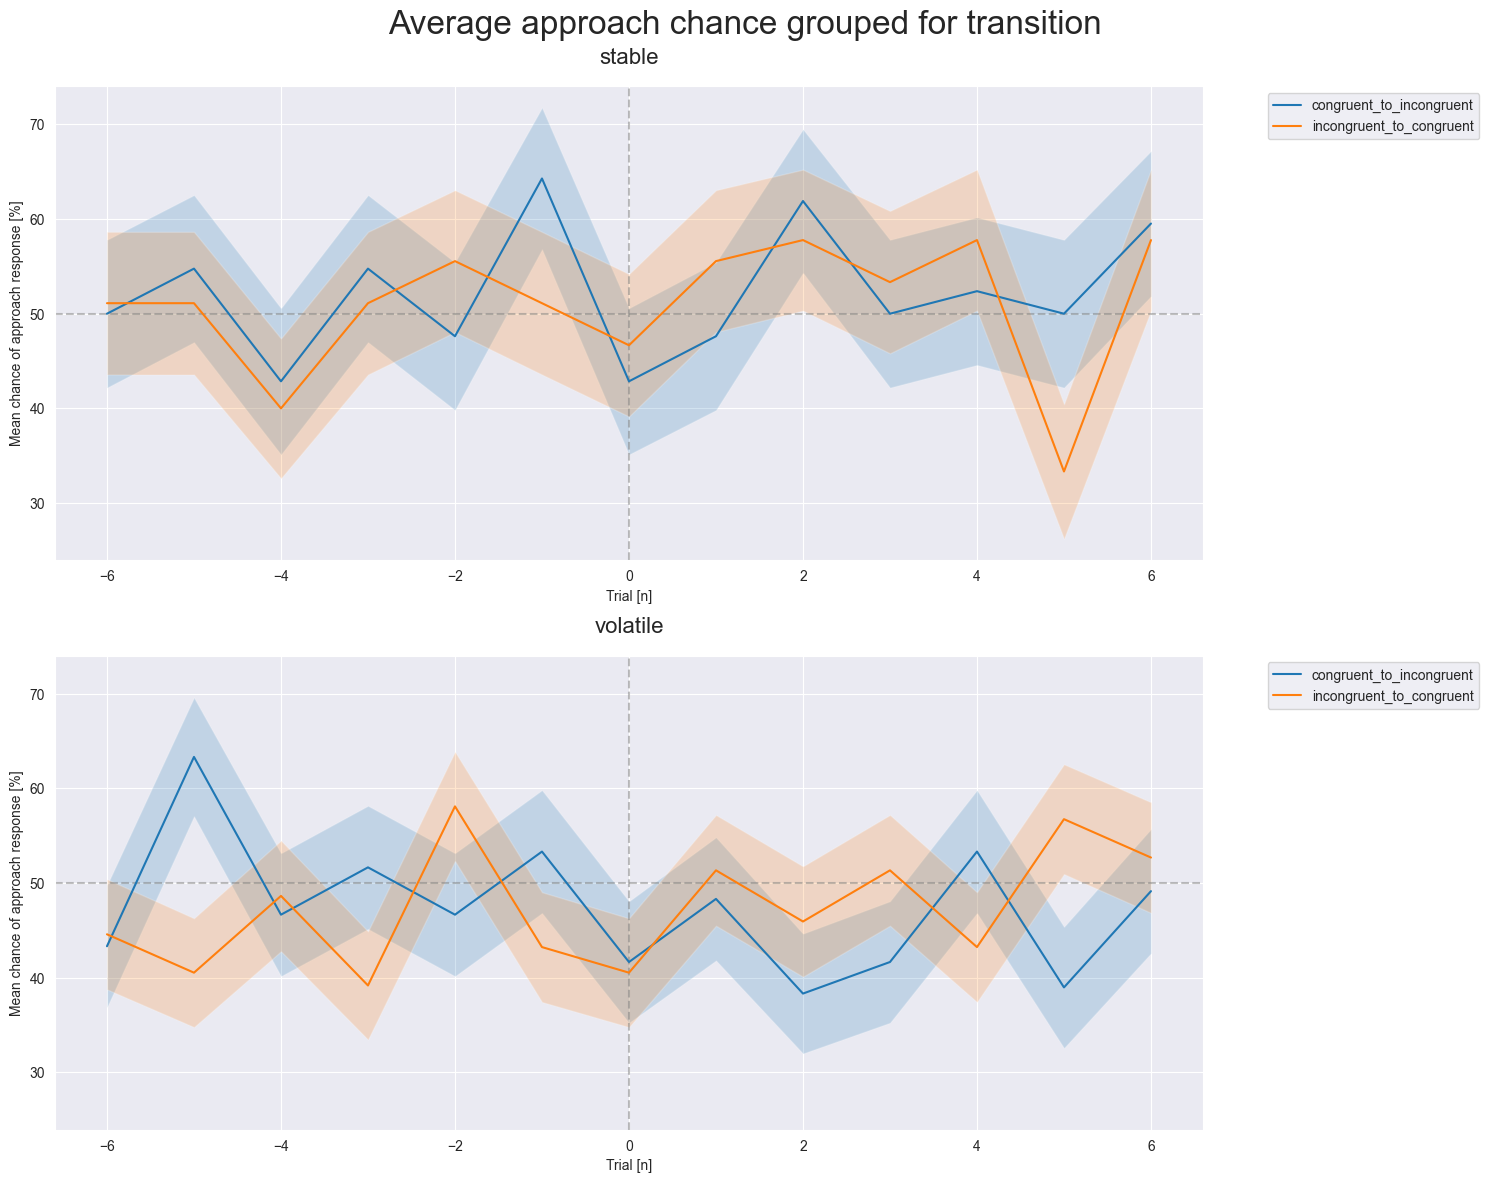

In [247]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()